# Document Scanner - 02: Perspective Correction & Scan

Take the 4 corners found in notebook 01, warp them to a flat top-down rectangle, then adaptive-threshold to a black-on-white scan.

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils

## 1. Run the full pipeline

In [2]:
img = utils.load_image('data/document_photo.jpg')
res = utils.scan(img)
print('page found:', res['quad'] is not None)
print('warped size:', None if res['warped'] is None else res['warped'].shape)

page found: True
warped size: (804, 709, 3)


## 2. Ordered corners (TL, TR, BR, BL)

In [3]:
rect = utils.order_points(res['quad'])
for name,p in zip(['top-left','top-right','bottom-right','bottom-left'], rect):
    print('%-13s (%d, %d)' % (name, p[0], p[1]))

top-left      (178, 118)
top-right     (761, 58)
bottom-right  (821, 860)
bottom-left   (118, 761)


## 3. Before vs after

Left: original skewed photo. Middle: perspective-corrected page. Right: final thresholded scan.

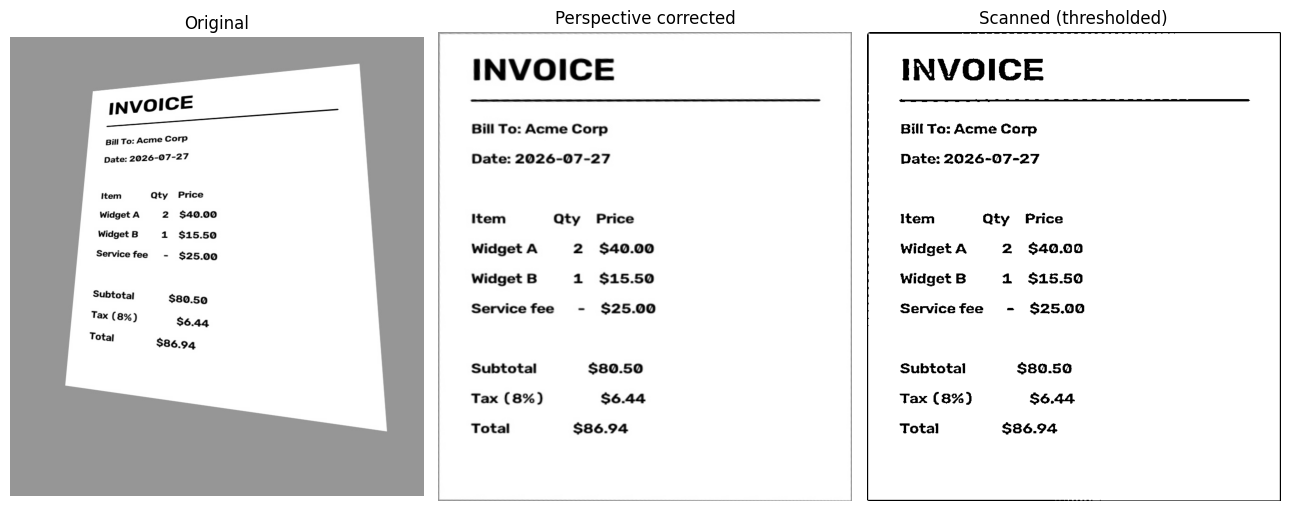

In [4]:
fig, ax = plt.subplots(1,3, figsize=(13,5))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(res['warped']); ax[1].set_title('Perspective corrected'); ax[1].axis('off')
ax[2].imshow(res['scanned'], cmap='gray'); ax[2].set_title('Scanned (thresholded)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

### Finding
The warp turns a slanted, background-cluttered photo into a rectangular page, and adaptive thresholding drops the background to pure white while keeping the text crisp. This is the same core trick mobile scanner apps use (CamScanner, Notes document scan): detect quad -> homography warp -> binarize.